Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform
following tasks:
1. Pre-process the dataset.
2. Identify outliers.
3. Check the correlation.
4. Implement linear regression model.
5. Evaluate the model using R2, RMSE, etc.

Use Uber Dataset:
[Uber.csv](https://www.kaggle.com/datasets/yasserh/uber-fares-dataset)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### What are the libraries used in the code? Explain each.
1. **pandas (imported as pd)**: 
   - A library used for handling and analyzing data. It provides data structures like DataFrames, which make it easier to work with tabular data (like CSV files or Excel spreadsheets).
   - You can clean, manipulate, and analyze large datasets efficiently with pandas.

2. **numpy (imported as np)**: 
   - A fundamental package for numerical computing in Python. It provides support for arrays and matrices, as well as a large collection of mathematical functions to perform operations on these arrays.

3. **matplotlib.pyplot (imported as plt)**: 
   - A plotting library used to create graphs and visualizations. It helps in creating static, interactive, and animated plots, such as line graphs, bar charts, and histograms.

4. **seaborn (imported as sns)**: 
   - A data visualization library based on matplotlib. It provides a high-level interface to create attractive and informative statistical graphics, such as heatmaps, box plots, and violin plots.

5. **train_test_split (from sklearn.model_selection)**: 
   - A function used to split your dataset into two parts: one for training a model and the other for testing its performance. Typically, the data is split into training and testing sets, with the training set used to train the model and the testing set used to evaluate how well it generalizes to new data.

6. **LinearRegression (from sklearn.linear_model)**: 
   - A machine learning algorithm used for predicting a continuous target variable (like price, temperature, etc.) based on one or more input features. It works by fitting a line (or hyperplane in higher dimensions) to the data.

7. **r2_score, mean_squared_error, mean_absolute_error (from sklearn.metrics)**: 
   - These are evaluation metrics used to assess the performance of a regression model.
     - **r2_score**: Measures how well the model’s predictions match the actual data. A value closer to 1 means a better fit.
     - **mean_squared_error (MSE)**: Measures the average of the squared differences between predicted and actual values. Lower values indicate better performance.
     - **mean_absolute_error (MAE)**: Measures the average of the absolute differences between predicted and actual values. Like MSE, lower values indicate better model performance.

In [3]:
data = pd.read_csv('D:/KAUSTUBH/LP3 Final/uber.csv')
print(data.head())

   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217                1  
1         -73.994710         40.750325                1  
2         -73.962565         40.772647                1  
3         

<h1>Data Preprocessing</h1>
<h3>What is data preprocessing? What are the steps in data preprocessing?</h3>
Data preprocessing is an essential step in machine learning. It involves preparing and cleaning data before feeding it into a model. The goal is to make the data suitable for analysis, improving the accuracy and efficiency of machine learning models. Here are the main steps involved:

1. **Data Collection**: First, you gather the raw data from various sources (like surveys, databases, or sensors).

2. **Data Cleaning**: Data often contains errors or missing values. Cleaning the data involves:
   - **Handling Missing Values**: Sometimes, certain data points are missing. You can fill in these gaps by replacing them with the mean, median, or mode of the data, or by using more advanced techniques.
   - **Removing Outliers**: Outliers are extreme values that don't fit with the rest of the data. They can distort the model's predictions, so it's important to identify and remove or correct them.
   - **Fixing Errors**: Incorrect data, such as typographical errors or inconsistent formats, needs to be corrected.

3. **Data Transformation**: The raw data might not be in a form that works well for a machine learning model. Data transformation helps convert it into a suitable format:
   - **Normalization**: If features (variables) in your data have different ranges (e.g., age ranges from 0 to 100, but income ranges from 1000 to 1 million), normalization scales them to a common range.
   - **Standardization**: This adjusts data to have a mean of 0 and a standard deviation of 1, making it easier for the model to understand patterns.

4. **Feature Engineering**: This step involves creating new variables (called "features") from the existing data. For example, if you have "height" and "weight" data, you might create a new feature, "BMI," to help the model better understand the relationship between them.

5. **Data Splitting**: Before training a machine learning model, the data is usually split into two main sets:
   - **Training Data**: This data is used to train the model.
   - **Testing Data**: After the model is trained, this data is used to evaluate how well the model performs.

6. **Encoding Categorical Data**: Some machine learning algorithms only work with numbers, so categorical data (like "red," "blue," or "green") needs to be converted into a numeric format. This can be done by methods like **one-hot encoding** or **label encoding**.

**Why is Data Preprocessing Important?**

Data preprocessing is crucial because raw data is often messy, incomplete, or unstructured. A good preprocessing step ensures that the data is clean, relevant, and structured in a way that the machine learning algorithm can learn from it efficiently. Without proper preprocessing, models may produce inaccurate or biased results.

In [4]:
# Drop irrelevant columns
data = data.drop(["Unnamed: 0","key"], axis=1)

# Check for missing values in the dataset
missing_values = data.isnull().sum()

# Drop rows with missing values (as they are minimal)
data = data.dropna()

# Convert pickup_datetime to datetime format and extract useful time features
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'], errors='coerce')
data['pickup_day'] = data['pickup_datetime'].dt.day
data['hour'] = data['pickup_datetime'].dt.hour
data['day'] = data['pickup_datetime'].dt.dayofweek

# Verify the preprocessing
data.head(), missing_values

(   fare_amount           pickup_datetime  pickup_longitude  pickup_latitude  \
 0          7.5 2015-05-07 19:52:06+00:00        -73.999817        40.738354   
 1          7.7 2009-07-17 20:04:56+00:00        -73.994355        40.728225   
 2         12.9 2009-08-24 21:45:00+00:00        -74.005043        40.740770   
 3          5.3 2009-06-26 08:22:21+00:00        -73.976124        40.790844   
 4         16.0 2014-08-28 17:47:00+00:00        -73.925023        40.744085   
 
    dropoff_longitude  dropoff_latitude  passenger_count  pickup_day  hour  day  
 0         -73.999512         40.723217                1           7    19    3  
 1         -73.994710         40.750325                1          17    20    4  
 2         -73.962565         40.772647                1          24    21    0  
 3         -73.965316         40.803349                3          26     8    4  
 4         -73.973082         40.761247                5          28    17    3  ,
 fare_amount          0
 

The **Euclidean distance** formula calculates the straight-line distance between two points in a space. In 2D (two dimensions), the formula is:

$$ 
d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2} 
$$


Where:
- \( (x_1, y_1) \) are the coordinates of the first point.
- \( (x_2, y_2) \) are the coordinates of the second point.
- \( d \) is the distance between these two points.

In simple terms, it measures how far apart two points are, assuming a flat plane, by finding the length of the shortest path (a straight line) connecting them. This formula is derived from the **Pythagorean theorem** and is commonly used in various fields like geometry, machine learning, and data analysis.

In [5]:
# Calculate distance
data['distance'] = np.sqrt((data['dropoff_longitude'] - data['pickup_longitude'])**2 + 
                           (data['dropoff_latitude'] - data['pickup_latitude'])**2)

In [6]:
# Filter outliers based on distance and fare
data = data[(data['distance'] < data['distance'].quantile(0.99)) &
            (data['fare_amount'] < data['fare_amount'].quantile(0.99))]

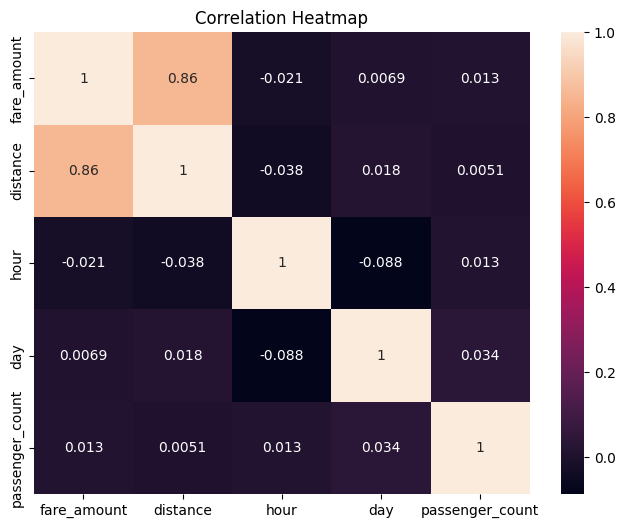

In [7]:
# Check correlation
plt.figure(figsize=(8, 6))
sns.heatmap(data[['fare_amount', 'distance', 'hour', 'day', 'passenger_count']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [8]:
# Prepare data for training
X = data[['distance', 'hour', 'day', 'passenger_count']]
y = data['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h3>What is linear regression? What is best fit line?</h3>
- Regression analysis is a statistical technique used to model the relationship between a dependent variable (also called the outcome or response variable) and one or more independent variables (also called predictors or explanatory variables).
- The goal of regression analysis is to understand how changes in the independent variables are associated with changes in the dependent variable.
- It is widely used for prediction, forecasting, and understanding the relationships between variables in various fields such as economics, finance, social sciences, and engineering.

### Linear Regression: An Overview

Linear regression is a simple and widely used machine learning algorithm for predicting a continuous value based on the relationship between input variables. It is called "linear" because it assumes that the relationship between the input variables (also called features or predictors) and the target variable (what you're trying to predict) can be represented as a straight line.

### The Basics of Linear Regression

In **linear regression**, we try to find the best-fitting straight line that represents the relationship between the input data and the output prediction.

The equation for a simple linear regression (with one input variable) looks like this:

y = mx + b

Where:
- y is the predicted value (the output),
- x is the input value (the feature),
- m is the **slope** of the line, and
- b is the **intercept** (the point where the line crosses the y-axis).

### When to Use Linear Regression?

Linear regression is most useful when:
- The relationship between variables is approximately linear.
- You want to predict a continuous outcome.
- The dataset is not too large, as linear regression can become inefficient with complex data.

In [9]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
# Evaluate model
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.7318091906005604
RMSE: 3.9063550842642774
MAE: 2.2734376848780746


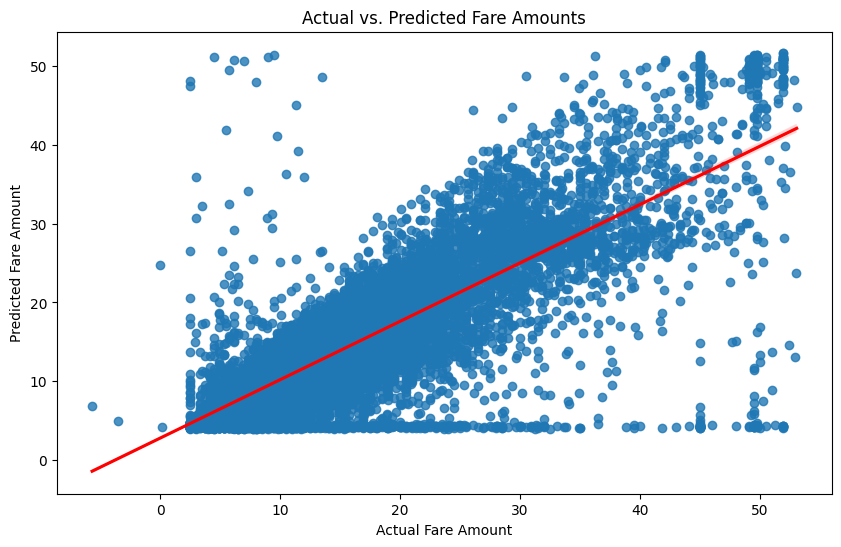

In [11]:
# Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, line_kws={'color': 'red'})
plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Actual vs. Predicted Fare Amounts")
plt.show()